In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parameters
e0 = 1 
mu0 = 1 
vp = 1 / np.sqrt(e0 * mu0)

a = 1 # tamanho da reta (eixo x)
T = 1 # tempo de simulação 

dx = 0.02
dt = dx / 2
# dt = dx

nx = int(a / dx)
nt = int(T / dt)

xgrid = np.linspace(0, a, nx) # xgrid para o Ey
tgrid = np.linspace(0, T, nt) # tgrid para o Ey

xgrid_interc = np.linspace(dx / 2, a - dx / 2, nx - 1) # xgrid para o Hz
tgrid_interc = np.linspace(dt / 2, T - dt / 2, nt - 1) # tgrid para o Hz

# campos
Ey = np.zeros((nt, nx))
Hz = np.zeros((nt, nx-1))

# valor inicial do campo Ey em t = 0
Ey[0, :] = np.sin(np.pi / a * xgrid)

# marcha no tempo
for n in range(nt - 1):
    # atualiza o H
    Hz[n+1, :] = Hz[n, :] - (dt / (mu0 * dx)) * (Ey[n, 1:] - Ey[n, :-1])

    # atualiza o E
    Ey[n+1, 1:-1] = Ey[n, 1:-1] - (dt / (e0 * dx)) * (Hz[n+1, 1:] - Hz[n+1, :-1])

    # zero na condição de contorno (extremidades)
    Ey[n+1, 0] = 0
    Ey[n+1, -1] = 0



In [2]:
# preenche com a solução exata
# campos
Ey_exact = np.zeros((nt, nx))
Hz_exact = np.zeros((nt, nx-1))

for n in range(nt):
    for i in range(nx):
        curr_t_ey = tgrid[n]
        curr_x_ey = xgrid[i]

        Ey_exact[n, i] = np.cos(vp * np.pi / a * curr_t_ey) * np.sin(np.pi / a * curr_x_ey)
        if i < nx - 1 and n < nt - 1:
            curr_x_hz = xgrid_interc[i]
            curr_t_hz = tgrid_interc[n]
            Hz_exact[n, i] = -1 * np.sin(vp * np.pi / a * curr_t_hz) * np.cos(np.pi / a * curr_x_hz)

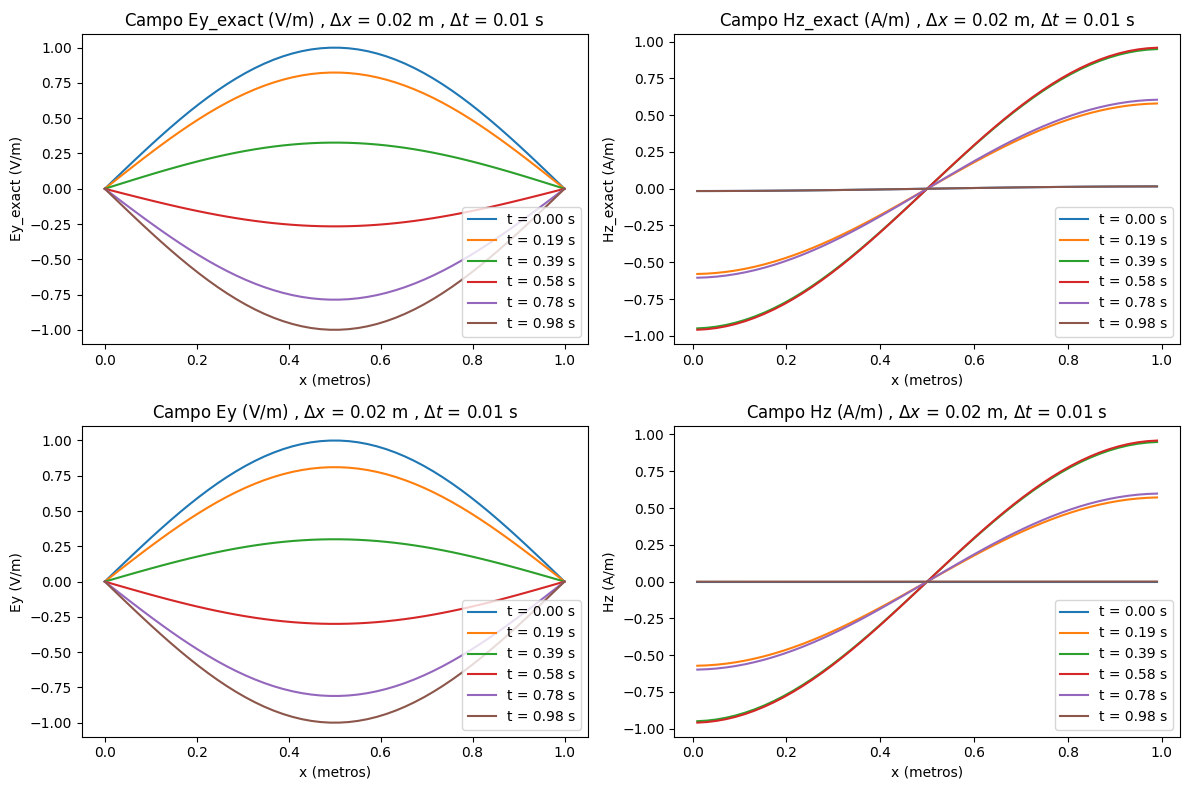

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
t_list = np.linspace(0, nt - 2, 6, dtype=int)

for k in range(len(t_list)):
    axes[0,0].plot(xgrid, Ey_exact[t_list[k], :], label=f"t = {t_list[k] * dt:.2f} s")
axes[0,0].set_title(fr"Campo Ey_exact (V/m) , $\Delta x$ = {dx} m , $\Delta t$ = {dt} s")
axes[0,0].set_xlabel("x (metros)")
axes[0,0].set_ylabel(f"Ey_exact (V/m)")
axes[0,0].legend(loc='lower right')

for k in range(len(t_list)):
    axes[0,1].plot(xgrid_interc, Hz_exact[t_list[k], :], label=f"t = {t_list[k] * dt:.2f} s")
axes[0,1].set_title(fr"Campo Hz_exact (A/m) , $\Delta x$ = {dx} m, $\Delta t$ = {dt} s")
axes[0,1].set_xlabel("x (metros)")
axes[0,1].set_ylabel(f"Hz_exact (A/m)")
axes[0,1].legend(loc='lower right')

for k in range(len(t_list)):
    axes[1,0].plot(xgrid, Ey[t_list[k], :], label=f"t = {t_list[k] * dt:.2f} s")
axes[1,0].set_title(fr"Campo Ey (V/m) , $\Delta x$ = {dx} m , $\Delta t$ = {dt} s")
axes[1,0].set_xlabel("x (metros)")
axes[1,0].set_ylabel(f"Ey (V/m)")
axes[1,0].legend(loc='lower right')

for k in range(len(t_list)):
    axes[1,1].plot(xgrid_interc, Hz[t_list[k], :], label=f"t = {t_list[k] * dt:.2f} s")
axes[1,1].set_title(fr"Campo Hz (A/m) , $\Delta x$ = {dx} m, $\Delta t$ = {dt} s")
axes[1,1].set_xlabel("x (metros)")
axes[1,1].set_ylabel(f"Hz (A/m)")
axes[1,1].legend(loc='lower right')

plt.tight_layout()
plt.show()